In [1]:
import pandas as pd
import plotly.express as px
import datetime

In [2]:
df = pd.read_csv("posts.csv")
df.created_at = pd.to_datetime(df["created_at"]).dt.date
df_filtered = df.copy()
df

,title,body,created_at,author
0,A finicky pine consists authorisation.,A fallacious lounge trots dam.\nA frantic coev...,2025-11-03,Thomas FORNEROD
1,The adamant wardrobe leaves pricing.,An overt jasmine twists neighbour.\nThe abashe...,2025-11-03,Thomas FORNEROD
2,The auspicious proposition solves minion.,The watchful country thinks antling.\nWorkable...,2025-10-31,Richard VUADENS
3,A dispensable plunger trips turban.,A painstaking mandolin untidies insomnia.\nA p...,2025-11-02,Thomas SHAKIBAIE
4,Swift crush bangs unibody.,The black cowbell educates war.\nThe vigorous ...,2025-11-02,Julien DUPRAZ
...,...,...,...,...
95,The wholesale total budgets self.,An elfin interior prays nestling.\nAn outrageo...,2025-11-05,Thomas SHAKIBAIE
96,The freezing sausage launches chocolate.,A workable iron shows octet.\nThoughtful madam...,2025-10-29,Luis BERNARDINO
97,The grumpy saddle withstands privacy.,A husky thermometer treads soda.\nAquatic comp...,2025-11-05,Allan TSCHERNIA
98,The clear doubter troubles coast.,Super rate classifies terrapin.\nA hot recorde...,2025-10-29,Luis BERNARDINO


In [3]:
post_per_date: pd.DataFrame = df_filtered.groupby("created_at").size()
post_per_date

created_at
2025-10-28     5
2025-10-29    12
2025-10-30     8
2025-10-31     7
2025-11-01    11
2025-11-02     9
2025-11-03    19
2025-11-04    11
2025-11-05    13
2025-11-06     5
dtype: int64

In [4]:
post_per_date_bar = px.bar(post_per_date)
post_per_date_bar

In [5]:
authors = df_filtered.author.unique()
authors

array(['Thomas FORNEROD', 'Richard VUADENS', 'Thomas SHAKIBAIE',
       'Julien DUPRAZ', 'Allan TSCHERNIA', 'Steve VIONNET',
       'Mark RALLIE ALLADO', 'Shahan MOHAMED', 'Stanislas GIGANDET',
       'Luis BERNARDINO', 'Lysi EKMEKCIU', 'Thibault FRATIANNI',
       'Wanid CHABANE', 'John ROSE', 'Carina DA FONSECA PINTO'],
      dtype=object)

In [6]:
post_per_author = df_filtered.loc[df_filtered.created_at.between(datetime.date(2025, 6, 1), datetime.date(2025, 6, 1))].groupby("author").size()
post_per_author

Series([], dtype: int64)

<Axes: xlabel='created_at,author'>

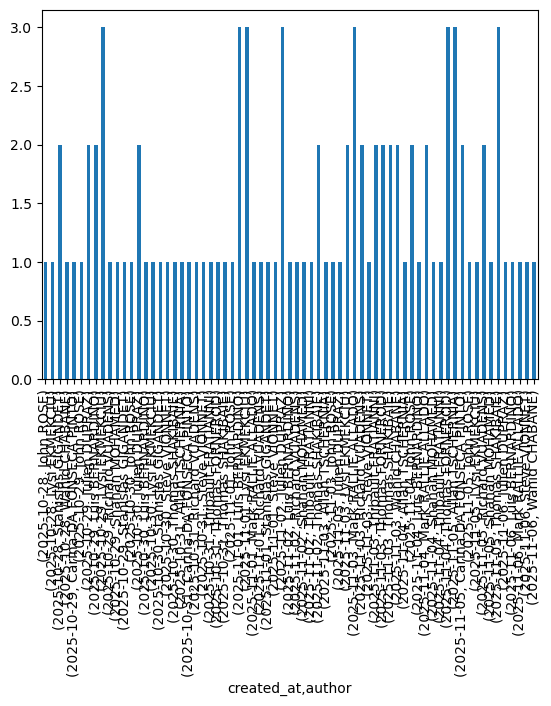

In [9]:
post_per_authors_and_date = df_filtered.groupby(["created_at", "author"]).size()
post_per_authors_and_date.plot.bar()

In [10]:
post_per_authors_date_bar = px.bar(
  post_per_authors_and_date, 
  x=post_per_authors_and_date.index.get_level_values(0), 
  y=post_per_authors_and_date.values, 
  color=post_per_authors_and_date.index.get_level_values(1)
)
post_per_authors_date_bar